# Humpback Whale Identification — ArcFace Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## ArcFace Training

**ArcFace** (Deng et al., CVPR 2019 — course slides 31–33) modifies the classification
head to enforce angular margin between classes on a hypersphere.

Instead of computing logits as `W · f(x)`, ArcFace:
1. L2-normalizes both weight vectors and embeddings
2. Computes cosine similarity (= angular distance on the hypersphere)
3. Adds an angular penalty `m` to the correct class's angle
4. Scales by factor `s` before softmax

This forces the model to cluster same-class embeddings tightly and push different
classes apart by at least `m` radians. The key advantage over triplet loss:
**no pair/triplet mining is needed** — ArcFace works with standard batching (slide 31).

We initialize from the baseline's backbone + embedding weights, replacing only
the classifier head with the ArcFace head.


## Setup & Imports

In [1]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_dataloaders,
 )
from models import build_model
from training import train
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


## Experiment Configuration

In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="arcface_effnetb5",
    description="ArcFace angular margin loss, initialized from baseline",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="arcface",       # ← ArcFace head instead of linear
    arcface_scale=30.0,        # Logit scale factor
    arcface_margin=0.5,        # Angular margin (radians)

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=3,  # Shorter freeze: backbone is already good from baseline
    freeze_bn=True,
    epochs=35,
    batch_size=16,
    accumulation_steps=2,
    use_amp=False,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,              # Slightly lower than baseline (fine-tuning, not fresh)
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="arcface_ce",    # Standard CE on the ArcFace-modified logits
    label_smoothing=0.0,       # No label smoothing with ArcFace (margin handles it)
    use_class_weights=False,   # ArcFace margin handles class separation

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=3,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    # UPDATE THIS PATH to your best baseline checkpoint:
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("ArcFace config:")
print(config.summary())

print(f"init_from_checkpoint: {config.init_from_checkpoint}")


ArcFace config:
efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=16×2 | head=arcface(s=30.0,m=0.5)
init_from_checkpoint: None


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [4]:
TRAINING_ENABLED = True
EXPERIMENT_ID = "unknown"

if TRAINING_ENABLED:
    #manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

[17:11:22] New experiment: 20260527_171122_arcface_effnetb5_2bb8ad39
[17:11:22] Config: efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=16×2 | head=arcface(s=30.0,m=0.5)
[17:11:22] No matching resume target found. Starting new experiment.
[17:11:23] Backbone FROZEN for first 3 epochs

Model: efficientnet_b5 (head=arcface)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,566,896
  Backbone:         28,340,784
  Head:              3,226,112
  Trainable:         3,226,112 (10.2%)
  Frozen:           28,340,784 (89.8%)

[17:11:23] Loss: arcface_ce | Head: arcface
[17:11:23] 
Starting training: 35 epochs, effective batch size = 32


  Train Ep 0:   0%|          | 0/465 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/233 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0ea311a700>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0ea311a700>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

  Extracting embeddings:   0%|          | 0/39 [00:00<?, ?it/s]

...

  Train Ep 29:   0%|          | 0/465 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/233 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/39 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

[19:16:00] Epoch  29/35 [UNFROZEN] | Train Loss: 0.6350  Acc: 99.9% | Val known_recall@1: 65.1%  LR: 4.51e-06 | Time: 4.2m
[19:16:01] 
Early stopping triggered (no improvement for 6 epochs)
[19:16:01] 
Training complete in 124.6 minutes.
[19:16:01] Best epoch: 23 (known_recall@1=0.6539)


## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


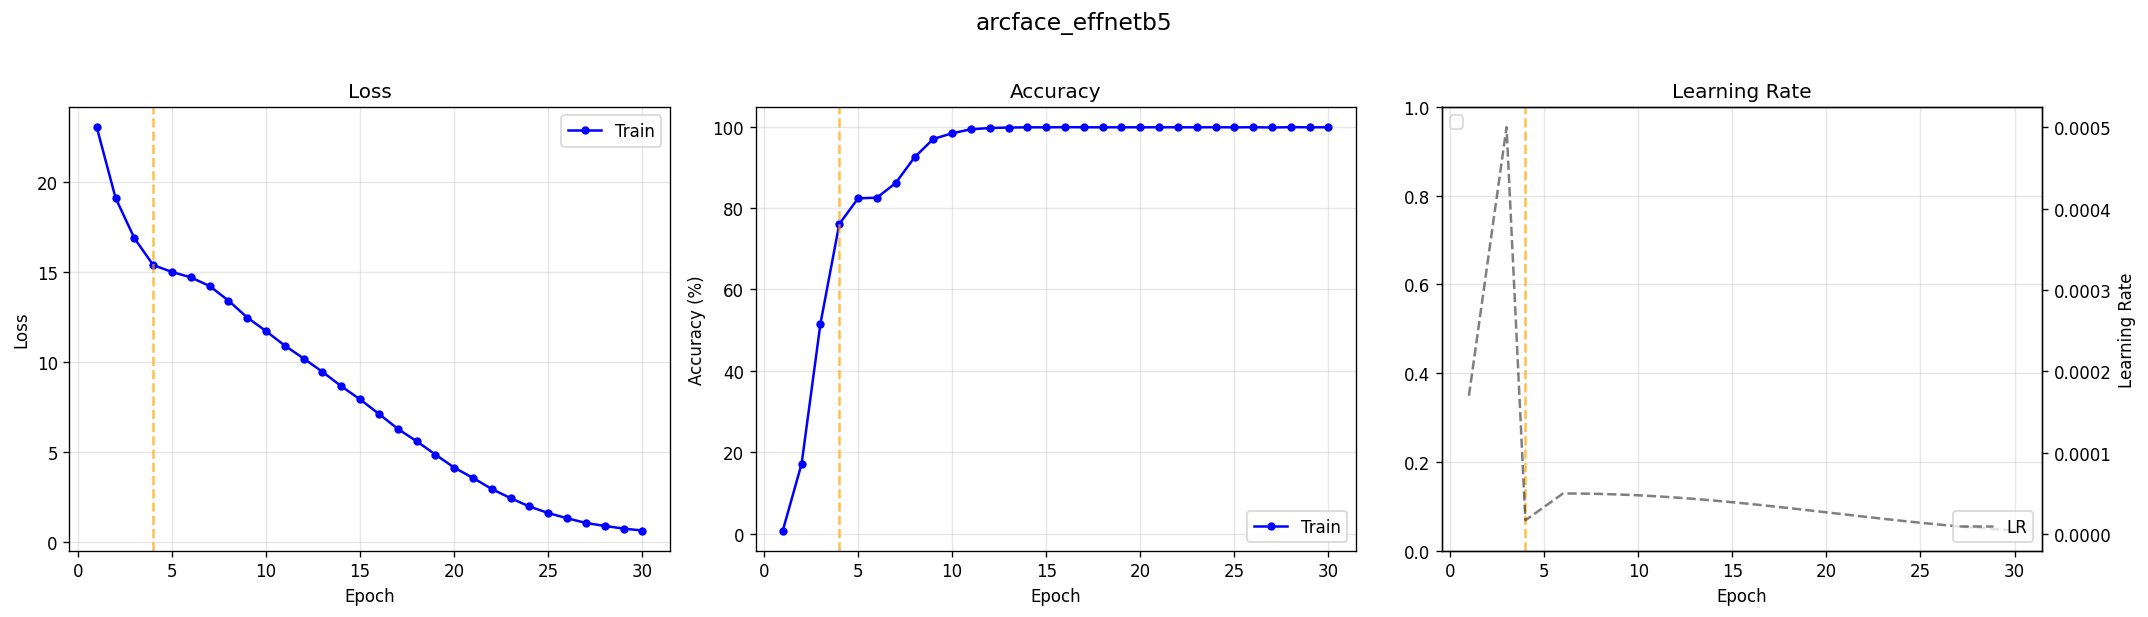

In [8]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [ ]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "train_acc", "known_recall@1", 
            "known_recall@5", "mean_known_conf", "mean_new_whale_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.6350


## Embedding Quality


In [7]:
eval_config, data = get_eval_config_and_data()

arcface_model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(arcface_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("ArcFace retrieval performance:")
arcface_retrieval = evaluate_retrieval(
    arcface_model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(arcface_model, val_loader, data, device,
                    title="ArcFace Embedding — t-SNE", combine_loaders=[train_loader])

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)


[19:16:02] Loading checkpoint: experiments/20260527_171122_arcface_effnetb5_2bb8ad39/checkpoints/best.pth
[19:16:53] Resuming from epoch 24
ArcFace retrieval performance:


NameError: name 'evaluate_retrieval' is not defined